In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import os
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv(r"..\csv\cleaned_data.csv")
print("Forma del dataset:", df.shape)
print("\nPrimeras filas:")
df.head()

Forma del dataset: (30552, 14)

Primeras filas:


,Campaña,Pedido,Zona,Dirección entrega,Telefono,Barrio,Ciudad,Fecha recibo LD,Fecha reparto,Fecha entrega,Transportador,Estado,horas_entrega,umbral
0,202407,37087842,601,KR 47A 48 39- TEL 0-3143423923,0-3143423923,CORDOBA,CALI (VALLE),2024-04-27 19:07:31,2024-04-29 10:43:16,2024-04-29 22:08:43,CBZ922,A TIEMPO,11.424167,24
1,202407,37093297,580,CR 1H NORTE 77-10 SEGUNDO PISO- TEL 0-3154678944,0-3154678944,COMFENALCO,CALI (VALLE),2024-04-27 19:04:43,2024-04-28 10:24:04,2024-04-28 16:40:32,TZY274,A TIEMPO,6.274444,24
2,202407,37098642,594,CALLETERSERA SN124- TEL 0-3016931064,0-3016931064,PROVIVIENDA,DAGUA (VALLE),2024-04-28 20:40:40,2024-04-29 11:18:40,2024-04-30 12:00:25,TZN919,A TIEMPO,24.695833,48
3,202407,37105003,603,CL 18 A 9 A 11 PISO NO 1- TEL 0-3136142043,0-3136142043,CARLOS GUZMAN,PUERTO TEJADA (CAUCA),2024-05-04 09:36:18,2024-05-04 13:10:03,2024-05-05 23:00:44,CEN356,A TIEMPO,33.844722,48
4,202407,37111291,603,KR 18 15 A 40- TEL 0-3125418458,0-3125418458,LA SAMARIA,SANTANDER DE QUILICHAO (CAUCA),2024-05-04 09:18:31,2024-05-06 08:39:17,2024-05-06 22:00:29,TZY274,A TIEMPO,13.353333,48


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30552 entries, 0 to 30551
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Campaña            30552 non-null  int64  
 1   Pedido             30552 non-null  int64  
 2   Zona               30552 non-null  str    
 3   Dirección entrega  30552 non-null  str    
 4   Telefono           30552 non-null  str    
 5   Barrio             30552 non-null  str    
 6   Ciudad             30552 non-null  str    
 7   Fecha recibo LD    30552 non-null  str    
 8   Fecha reparto      30552 non-null  str    
 9   Fecha entrega      30552 non-null  str    
 10  Transportador      30552 non-null  str    
 11  Estado             30552 non-null  str    
 12  horas_entrega      30552 non-null  float64
 13  umbral             30552 non-null  int64  
dtypes: float64(1), int64(3), str(10)
memory usage: 7.7 MB


## Seleccion y arreglo de Features

In [5]:
# Seleccionar columnas relevantes
columnas_usar = ['Zona', 'Barrio', 'Ciudad', 'Fecha recibo LD', 
                  'Transportador']

df_modelo = df[columnas_usar].copy()
print("Columnas a usar:", columnas_usar)
print("\nTipos de datos:")
print(df_modelo.dtypes)
print("\nValores únicos por columna:")
for col in df_modelo.columns:
    print(f"{col}: {df_modelo[col].nunique()} valores únicos")

Columnas a usar: ['Zona', 'Barrio', 'Ciudad', 'Fecha recibo LD', 'Transportador']

Tipos de datos:
Zona               str
Barrio             str
Ciudad             str
Fecha recibo LD    str
Transportador      str
dtype: object

Valores únicos por columna:
Zona: 9 valores únicos
Barrio: 709 valores únicos
Ciudad: 36 valores únicos
Fecha recibo LD: 28095 valores únicos
Transportador: 24 valores únicos


In [6]:
df_modelo['Fecha recibo LD'] = pd.to_datetime(df_modelo['Fecha recibo LD'])


In [7]:
df_modelo["hora_recibo"] = df_modelo["Fecha recibo LD"].dt.hour
df_modelo["dia_semana_recibo"] = df_modelo["Fecha recibo LD"].dt.dayofweek
df_modelo["mes"] = df_modelo["Fecha recibo LD"].dt.month


In [8]:
df_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 30552 entries, 0 to 30551
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Zona               30552 non-null  str           
 1   Barrio             30552 non-null  str           
 2   Ciudad             30552 non-null  str           
 3   Fecha recibo LD    30552 non-null  datetime64[us]
 4   Transportador      30552 non-null  str           
 5   hora_recibo        30552 non-null  int32         
 6   dia_semana_recibo  30552 non-null  int32         
 7   mes                30552 non-null  int32         
dtypes: datetime64[us](1), int32(3), str(4)
memory usage: 2.5 MB


In [9]:
df_modelo = df_modelo.drop(columns=["Fecha recibo LD",])

In [10]:
salida = df['horas_entrega']

## Split train-test

In [11]:
x_train, x_test, y_train, y_test = train_test_split(df_modelo, salida, test_size=0.3, random_state=0)

In [12]:
print("x_train: ",x_train.shape)
print("y_train: ",y_train.shape)
print("x_test: ",x_test.shape)
print("y_test: ",y_test.shape)

x_train:  (21386, 7)
y_train:  (21386,)
x_test:  (9166, 7)
y_test:  (9166,)


## Barrio Target Encoding

In [13]:
barrio_mean = y_train.groupby(x_train["Barrio"]).mean()

x_train["barrio_encoded"] = x_train["Barrio"].map(barrio_mean)
x_test["barrio_encoded"] = x_test["Barrio"].map(barrio_mean)

global_mean = y_train.mean()

x_train["barrio_encoded"] = x_train["barrio_encoded"].fillna(global_mean)
x_test["barrio_encoded"] = x_test["barrio_encoded"].fillna(global_mean)

In [14]:
x_train = x_train.drop(columns=["Barrio"])
x_test = x_test.drop(columns=["Barrio"])

## One Hot Encoding a columnas categoricas

In [15]:
columnas_ohe = [
    "Ciudad",
    "Transportador",
]

In [16]:
x_train = pd.get_dummies(x_train, columns=columnas_ohe, drop_first=True)
x_test = pd.get_dummies(x_test, columns=columnas_ohe, drop_first=True)
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

In [17]:
le_zona = LabelEncoder()

x_train["Zona_encoded"] = le_zona.fit_transform(x_train["Zona"])
x_test["Zona_encoded"] = le_zona.transform(x_test["Zona"])

In [18]:
x_train = x_train.drop(columns=["Zona"])
x_test = x_test.drop(columns=["Zona"])

## Escalado y entrenamiento del modelo

In [19]:
print(x_train.info())

<class 'pandas.DataFrame'>
Index: 21386 entries, 554 to 2732
Data columns (total 62 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   hora_recibo                               21386 non-null  int32  
 1   dia_semana_recibo                         21386 non-null  int32  
 2   mes                                       21386 non-null  int32  
 3   barrio_encoded                            21386 non-null  float64
 4   Ciudad_BOGOTA (CUNDINAMARCA)              21386 non-null  bool   
 5   Ciudad_BUENOS AIRES CAUCA                 21386 non-null  bool   
 6   Ciudad_CALI (VALLE)                       21386 non-null  bool   
 7   Ciudad_CALOTO (CAUCA)                     21386 non-null  bool   
 8   Ciudad_CANDELARIA VALLE DEL CAUCA         21386 non-null  bool   
 9   Ciudad_CODAZZI (CESAR)                    21386 non-null  bool   
 10  Ciudad_CORINTO (CAUCA)                    21386 n

In [20]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=11,
    random_state=42,
    n_jobs=-1
)

In [21]:
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",11
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [22]:
y_pred_rf = rf.predict(x_test)

## Metricas y graficas

In [23]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest:
MAE: 9.015298721995794
RMSE: 13.391055181341656
R2: 0.6066922988890484


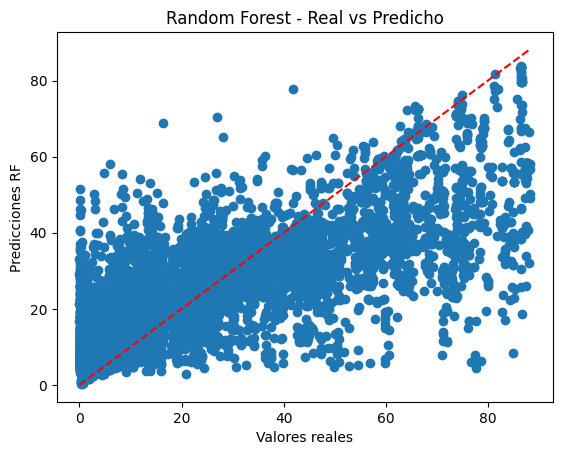

In [24]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--', color='red')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones RF")
plt.title("Random Forest - Real vs Predicho")
plt.show()

In [25]:
importancias = pd.Series(rf.feature_importances_, index=x_train.columns)
importancias = importancias.sort_values(ascending=False)

print(importancias.head(10))

barrio_encoded          0.396278
mes                     0.120891
hora_recibo             0.098370
dia_semana_recibo       0.095935
Transportador_TZY274    0.078146
Zona_encoded            0.036836
Transportador_WHU392    0.030776
Transportador_FJM605    0.021073
Transportador_YAB292    0.015704
Ciudad_CALI (VALLE)     0.013593
dtype: float64


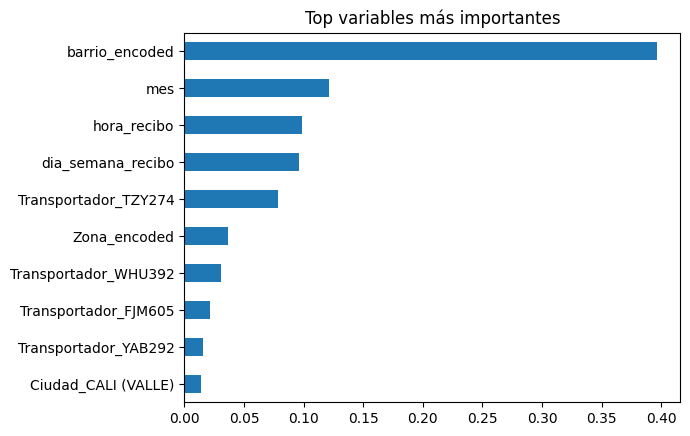

In [26]:
plt.figure()
importancias.head(10).plot(kind='barh')
plt.title("Top variables más importantes")
plt.gca().invert_yaxis()
plt.show()

## Creacion de umbral para matriz de confusion

In [27]:
umbral = np.where(
    x_test["Ciudad_CALI (VALLE)"] == 1,
    24,
    48
)

In [28]:
y_test_clase = (y_test <= umbral).astype(int)
y_pred_clase = (y_pred_rf <= umbral).astype(int)

[[1519  615]
 [ 703 6329]]


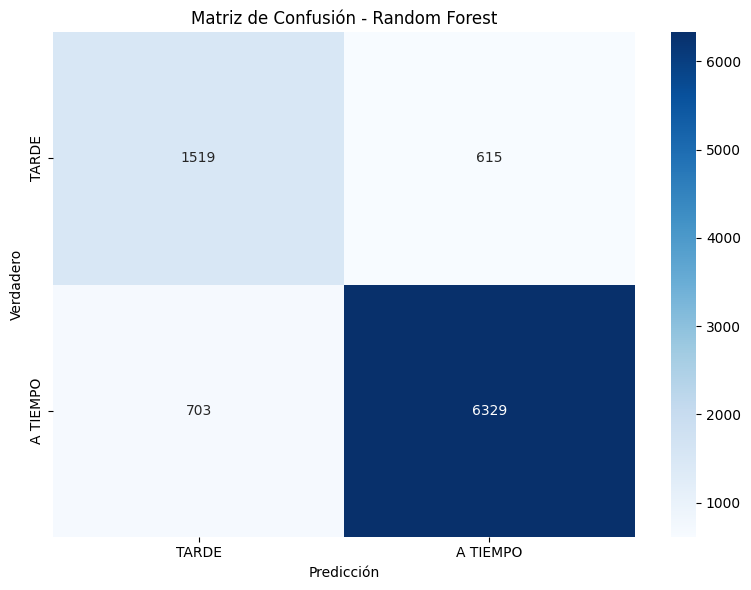

In [44]:
cm = confusion_matrix(y_test_clase, y_pred_clase)
print(cm)

# Visualizar
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['TARDE', 'A TIEMPO' ],
            yticklabels=['TARDE', 'A TIEMPO'],)
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Verdadero')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

In [30]:
print(classification_report(y_test_clase, y_pred_clase))

              precision    recall  f1-score   support

           0       0.68      0.71      0.70      2134
           1       0.91      0.90      0.91      7032

    accuracy                           0.86      9166
   macro avg       0.80      0.81      0.80      9166
weighted avg       0.86      0.86      0.86      9166



In [31]:
y_pred_train = rf.predict(x_train)

from sklearn.metrics import r2_score
print("R2 train:", r2_score(y_train, y_pred_train))
print("R2 test:", r2_score(y_test, y_pred_rf))

R2 train: 0.6996445391165107
R2 test: 0.6066922988890484


## XGBoost

In [32]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [33]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

In [34]:
xgb.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [35]:
y_pred = xgb.predict(x_test)

In [36]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

XGBoost:
MAE: 6.889450223672595
RMSE: 10.932049422254819
R2: 0.737876460534717


In [37]:
y_true_class = (y_test <= umbral).astype(int)
y_pred_class = (y_pred <= umbral + 7).astype(int)

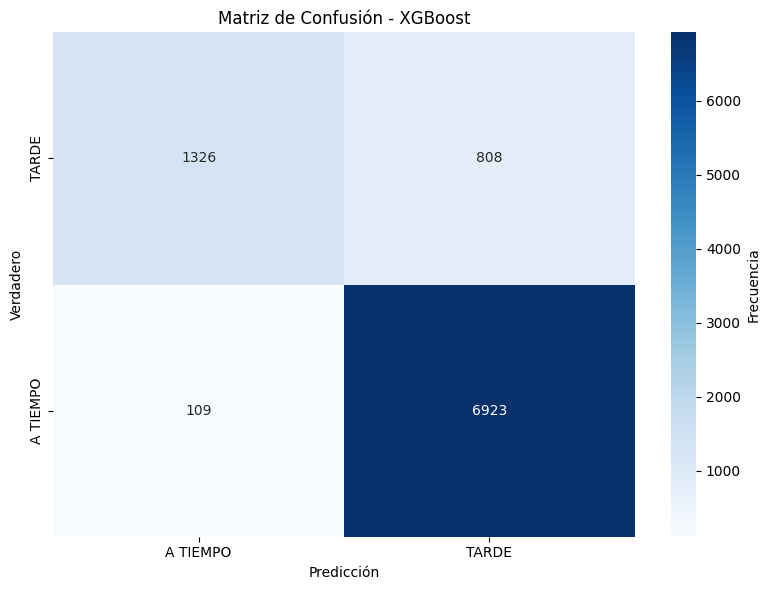

In [38]:
# Visualizar matriz de confusión XGBoost
cm_xgb = confusion_matrix(y_true_class, y_pred_class)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A TIEMPO', 'TARDE'],
            yticklabels=['TARDE', 'A TIEMPO'],
            cbar_kws={'label': 'Frecuencia'})
plt.title('Matriz de Confusión - XGBoost')
plt.ylabel('Verdadero')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()


In [39]:
print(classification_report(y_true_class, y_pred_class))

              precision    recall  f1-score   support

           0       0.92      0.62      0.74      2134
           1       0.90      0.98      0.94      7032

    accuracy                           0.90      9166
   macro avg       0.91      0.80      0.84      9166
weighted avg       0.90      0.90      0.89      9166



In [40]:
# Predicciones
y_train_pred = xgb.predict(x_train)
y_test_pred = xgb.predict(x_test)

# R²
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("R² Train:", r2_train)
print("R² Test:", r2_test)
print("Diferencia:", r2_train - r2_test)

R² Train: 0.8374114508229868
R² Test: 0.737876460534717
Diferencia: 0.09953499028826984


In [41]:
modelo_dir = "modelo_entrenado"
os.makedirs(modelo_dir, exist_ok=True)

# Guardar modelo XGBoost
modelo_path = os.path.join(modelo_dir, "xgb_regression_model.pkl")
with open(modelo_path, 'wb') as f:
    pickle.dump(xgb, f)